In [1]:
%reload_kedro

                    INFO     Resolved project path as:                                              ]8;id=121648;file://C:\Users\nicolas.betancourt\AppData\Local\anaconda3\envs\serpientes_env\lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=936553;file://C:\Users\nicolas.betancourt\AppData\Local\anaconda3\envs\serpientes_env\lib\site-packages\kedro\ipython\__init__.py#175\175]8;;\
                             C:\Users\nicolas.betancourt\Documents\GitHub\pytorch\serpientes-de-col                
                             ombia.                                                                                
                             To set a different path, run '%reload_kedro <project_root>'                           

                    INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=211163;file://C:\Users\nicolas.betancourt\AppData\Local\anaconda3\envs\serpientes_env\lib\site-packages\kedro_telemetry\plugin.py\plugin.py]8;;\:]8;id=181138;file://C:\Users\nicolas.betancourt\AppData\Local\anaconda3\envs\serpientes_env\lib\site-packages\kedro_telemetry\plugin.py#243\243]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/configuration/telemetry.html                         

[11/04/25 08:17:27] INFO     Kedro project serpientes_de_colombia                                   ]8;id=807854;file://C:\Users\nicolas.betancourt\AppData\Local\anaconda3\envs\serpientes_env\lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=316074;file://C:\Users\nicolas.betancourt\AppData\Local\anaconda3\envs\serpientes_env\lib\site-packages\kedro\ipython\__init__.py#141\141]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=519439;file://C:\Users\nicolas.betancourt\AppData\Local\anaconda3\envs\serpientes_env\lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=566319;file://C:\Users\nicolas.betancourt\AppData\Local\anaconda3\envs\serpientes_env\lib\site-packages\kedro\ipython\__init__.py#142\142]8;;\
                             'pipelines'                                                                           

                    INFO     Registered line magic 'run_viz'                                        ]8;id=581166;file://C:\Users\nicolas.betancourt\AppData\Local\anaconda3\envs\serpientes_env\lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=297455;file://C:\Users\nicolas.betancourt\AppData\Local\anaconda3\envs\serpientes_env\lib\site-packages\kedro\ipython\__init__.py#148\148]8;;\

In [2]:
import numpy as np
import pandas as pd
from torch.utils.data import random_split


In [21]:
image_urls     =catalog.load('image_urls@pandas'     )
train_size     =catalog.load('params:train_size'     )
validation_size=catalog.load('params:validation_size')

[11/04/25 08:47:50] INFO     Loading data from image_urls@pandas (CSVDataset)...                ]8;id=399985;file://C:\Users\nicolas.betancourt\AppData\Local\anaconda3\envs\serpientes_env\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=696199;file://C:\Users\nicolas.betancourt\AppData\Local\anaconda3\envs\serpientes_env\lib\site-packages\kedro\io\data_catalog.py#539\539]8;;\

                    INFO     Loading data from params:train_size (MemoryDataset)...             ]8;id=760558;file://C:\Users\nicolas.betancourt\AppData\Local\anaconda3\envs\serpientes_env\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=791606;file://C:\Users\nicolas.betancourt\AppData\Local\anaconda3\envs\serpientes_env\lib\site-packages\kedro\io\data_catalog.py#539\539]8;;\

                    INFO     Loading data from params:validation_size (MemoryDataset)...        ]8;id=883152;file://C:\Users\nicolas.betancourt\AppData\Local\anaconda3\envs\serpientes_env\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=746623;file://C:\Users\nicolas.betancourt\AppData\Local\anaconda3\envs\serpientes_env\lib\site-packages\kedro\io\data_catalog.py#539\539]8;;\

In [22]:
image_urls.head()

,url,observation_id,observation_date,taxa_id,rank,name,label,file_name
0,https://static.inaturalist.org/photos/58002956...,320776905,2025-09-22,30667,family,Viperidae,vibora,320776905_Viperidae.jpg
1,https://inaturalist-open-data.s3.amazonaws.com...,320719904,2025-08-28,30667,family,Viperidae,vibora,320719904_Viperidae.jpg
2,https://inaturalist-open-data.s3.amazonaws.com...,320719904,2025-08-28,30667,family,Viperidae,vibora,320719904_Viperidae.jpg
3,https://inaturalist-open-data.s3.amazonaws.com...,320719904,2025-08-28,30667,family,Viperidae,vibora,320719904_Viperidae.jpg
4,https://inaturalist-open-data.s3.amazonaws.com...,319964202,2025-10-10,30667,family,Viperidae,vibora,319964202_Viperidae.jpg


In [ ]:
image_urls=image_urls[['observation_date','file_name','label']]


image_urls=image_urls.sort_values(by='observation_date').reset_index(drop=True)
train_validation, test= image_urls[image_urls.index<len(image_urls)*(1-validation_size)], image_urls[image_urls.index>=len(image_urls)*(1-validation_size)]

train_validation['set']=train_validation.groupby('label')['label'].transform(lambda x: np.random.binomial(n=1,p=train_size, size=len(x)))


train, validation= train_validation=train_validation[train_validation['set']==1], train_validation[train_validation['set']==0]

In [15]:
len(train)/len(image_urls), len(validation)/len(image_urls),len(test)/len(image_urls)

(0.7153137593552101, 0.1848013816925734, 0.09988485895221647)

In [16]:
check_df=pd.concat([train.assign(cjto='train'),
           validation.assign(cjto='validation'), 
           test.assign(cjto='test')
          ])

<Axes: xlabel='cjto'>

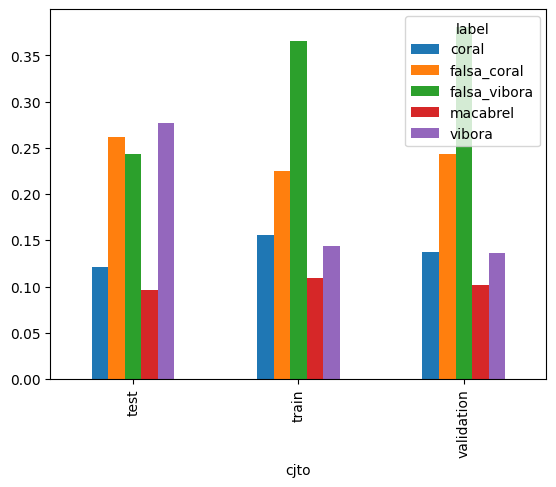

In [19]:
check_df.groupby('cjto')['label'].value_counts(normalize=True).unstack().plot(kind='bar')